In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.offline as py
import plotly.graph_objs as go
import plotly.tools as  tls
from warnings import filterwarnings
filterwarnings('ignore')

In [93]:
TrIns=pd.read_csv('TravelInsurancePrediction.csv')

In [94]:
TrIns.head()

,Unnamed: 0,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,0,31,Government Sector,Yes,400000,6,1,No,No,0
1,1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1
3,3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0
4,4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0


DATA PREPROSESSING AND CLEANING


In [95]:
TrIns.drop(['Unnamed: 0'],axis=1,inplace=True)

In [31]:
TrIns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1987 entries, 0 to 1986
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Age                  1987 non-null   int64 
 1   Employment Type      1987 non-null   object
 2   GraduateOrNot        1987 non-null   object
 3   AnnualIncome         1987 non-null   int64 
 4   FamilyMembers        1987 non-null   int64 
 5   ChronicDiseases      1987 non-null   int64 
 6   FrequentFlyer        1987 non-null   object
 7   EverTravelledAbroad  1987 non-null   object
 8   TravelInsurance      1987 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 139.8+ KB


In [32]:
TrIns.isnull().sum()

Age                    0
Employment Type        0
GraduateOrNot          0
AnnualIncome           0
FamilyMembers          0
ChronicDiseases        0
FrequentFlyer          0
EverTravelledAbroad    0
TravelInsurance        0
dtype: int64

In [33]:
dups=TrIns.duplicated()
TrIns[dups]

,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
69,31,Government Sector,No,300000,4,0,No,No,0
103,26,Private Sector/Self Employed,Yes,1400000,5,0,No,Yes,1
117,31,Government Sector,Yes,400000,5,0,No,No,0
148,25,Private Sector/Self Employed,Yes,1400000,4,0,No,Yes,1
164,28,Government Sector,Yes,300000,6,0,No,No,0
...,...,...,...,...,...,...,...,...,...
1978,34,Private Sector/Self Employed,Yes,700000,5,0,No,No,1
1979,28,Private Sector/Self Employed,Yes,1100000,4,1,No,No,0
1980,25,Private Sector/Self Employed,No,1150000,5,1,No,No,0
1984,28,Private Sector/Self Employed,Yes,1150000,6,1,No,No,0


In [34]:
TrIns.shape

(1987, 9)

In [35]:

TrIns.describe()

,Age,AnnualIncome,FamilyMembers,ChronicDiseases,TravelInsurance
count,1987.000000,1.987000e+03,1987.000000,1987.000000,1987.000000
mean,29.650226,9.327630e+05,4.752894,0.277806,0.357323
std,2.913308,3.768557e+05,1.609650,0.448030,0.479332
min,25.000000,3.000000e+05,2.000000,0.000000,0.000000
25%,28.000000,6.000000e+05,4.000000,0.000000,0.000000
50%,29.000000,9.000000e+05,5.000000,0.000000,0.000000
75%,32.000000,1.250000e+06,6.000000,1.000000,1.000000
max,35.000000,1.800000e+06,9.000000,1.000000,1.000000


EDA

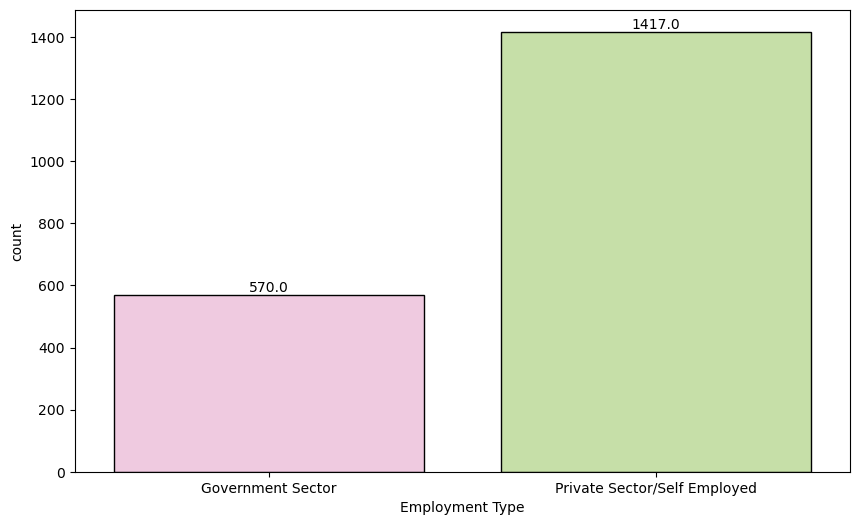

In [36]:
plt.figure(figsize=(10,6))
ax=sns.countplot(data=TrIns,x='Employment Type',palette='PiYG', edgecolor='black')
for p in ax.patches:
    ax.annotate(
        format((p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )
plt.show()

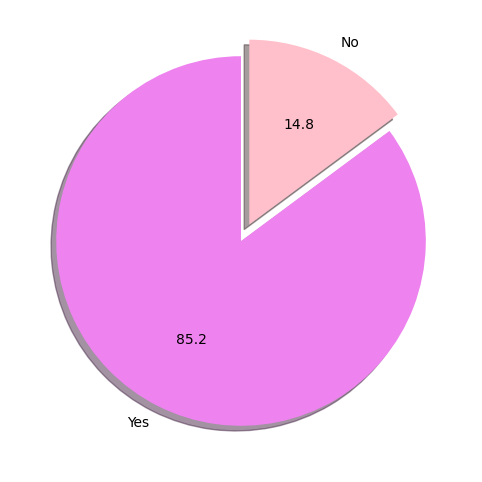

In [37]:
plt.figure(figsize=(10,6))
graduate_counts = TrIns['GraduateOrNot'].value_counts()
labels = graduate_counts.index
sizes = graduate_counts.values
plt.pie(sizes, labels=labels, autopct='%1.1f', explode=(0,0.1), startangle=90, shadow=True, colors=['violet','pink'])
plt.show()

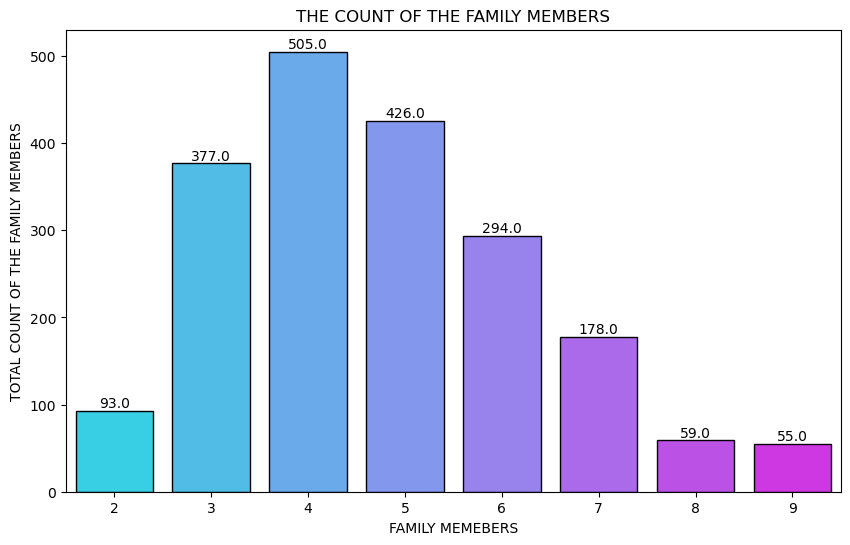

In [38]:
plt.figure(figsize=(10,6))
ax=sns.countplot(data=TrIns,x='FamilyMembers',palette='cool',edgecolor='black')
for p in ax.patches:
  ax.annotate(
        format((p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )
plt.title('THE COUNT OF THE FAMILY MEMBERS')
plt.xlabel('FAMILY MEMEBERS')
plt.ylabel('TOTAL COUNT OF THE FAMILY MEMBERS')
plt.show()


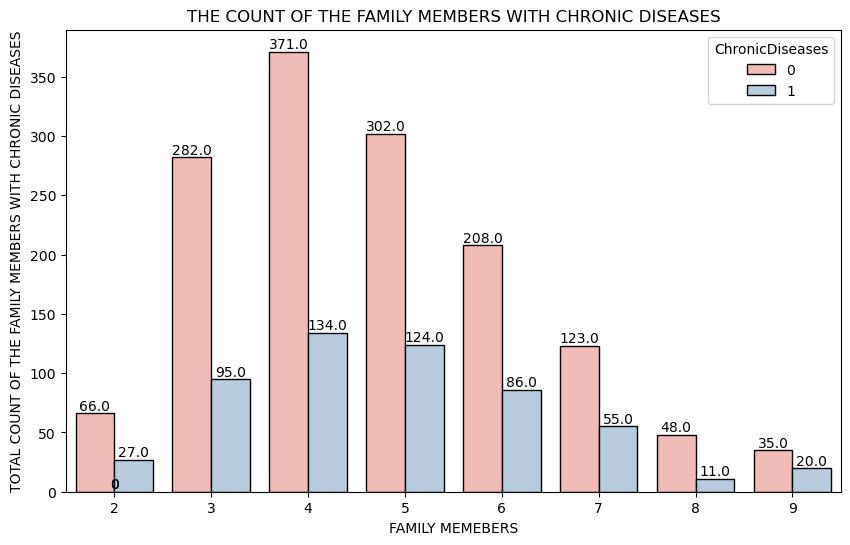

In [39]:
plt.figure(figsize=(10,6))
ax=sns.countplot(data=TrIns,x='FamilyMembers',hue='ChronicDiseases',palette='Pastel1',edgecolor='black')
for p in ax.patches:
  ax.annotate(
        format((p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )
plt.title('THE COUNT OF THE FAMILY MEMBERS WITH CHRONIC DISEASES')
plt.xlabel('FAMILY MEMEBERS')
plt.ylabel('TOTAL COUNT OF THE FAMILY MEMBERS WITH CHRONIC DISEASES')
plt.show()


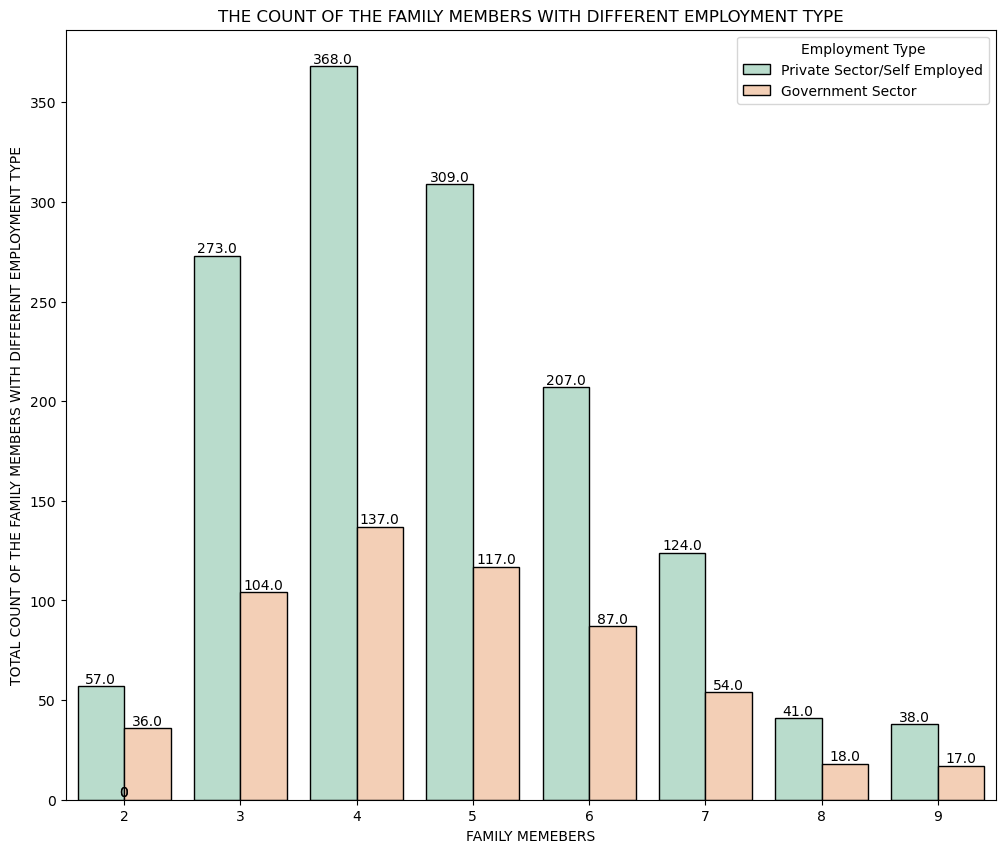

In [40]:
plt.figure(figsize=(12,10))
ax=sns.countplot(data=TrIns,x='FamilyMembers',hue='Employment Type',palette='Pastel2',edgecolor='black')
for p in ax.patches:
  ax.annotate(
        format((p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )
plt.title('THE COUNT OF THE FAMILY MEMBERS WITH DIFFERENT EMPLOYMENT TYPE')
plt.xlabel('FAMILY MEMEBERS')
plt.ylabel('TOTAL COUNT OF THE FAMILY MEMBERS WITH DIFFERENT EMPLOYMENT TYPE')
plt.show()

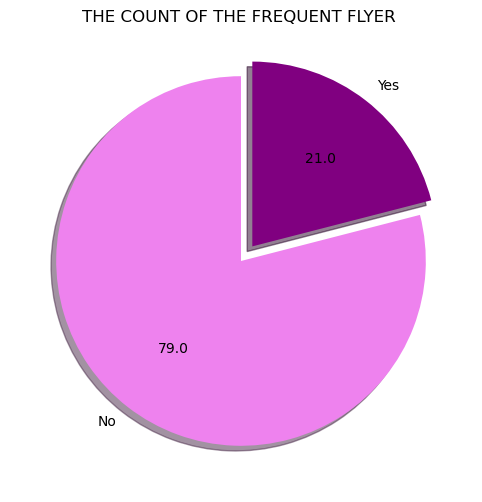

In [41]:
plt.figure(figsize=(10,6))
frequent_flyer_counts = TrIns['FrequentFlyer'].value_counts()
labels = frequent_flyer_counts.index
sizes =frequent_flyer_counts.values
plt.pie(sizes, labels=labels, autopct='%1.1f', explode=(0,0.1), startangle=90, shadow=True, colors=['violet','purple'])
plt.title("THE COUNT OF THE FREQUENT FLYER ")
plt.show()

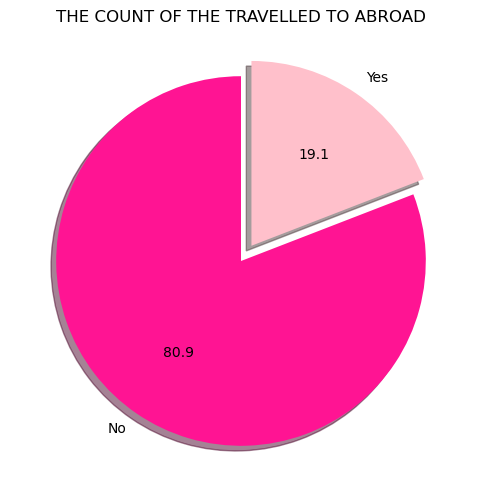

In [42]:
plt.figure(figsize=(10,6))
travelled_counts = TrIns['EverTravelledAbroad'].value_counts()
labels = travelled_counts.index
sizes =travelled_counts.values
plt.pie(sizes, labels=labels, autopct='%1.1f', explode=(0,0.1), startangle=90, shadow=True, colors=['deeppink','pink'])
plt.title("THE COUNT OF THE TRAVELLED TO ABROAD")
plt.show()

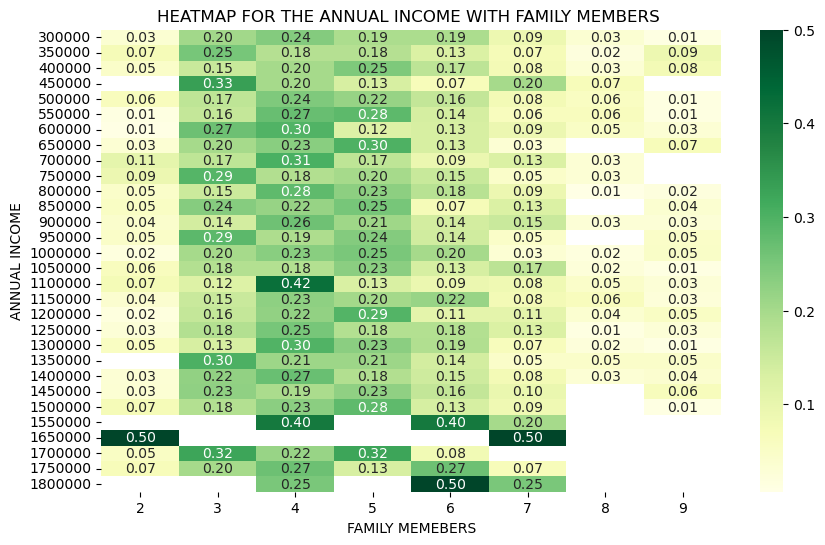

In [74]:
plt.figure(figsize=(10,6))
heatmap_data=TrIns.groupby(['AnnualIncome','FamilyMembers']).size().unstack()
heatmap_data=heatmap_data.div(heatmap_data.sum(axis=1),axis=0)
sns.heatmap(heatmap_data,annot=True,cmap='YlGn',fmt='.2f')
plt.title('HEATMAP FOR THE ANNUAL INCOME WITH FAMILY MEMBERS ')
plt.xlabel('FAMILY MEMEBERS')
plt.ylabel('ANNUAL INCOME')
plt.show()

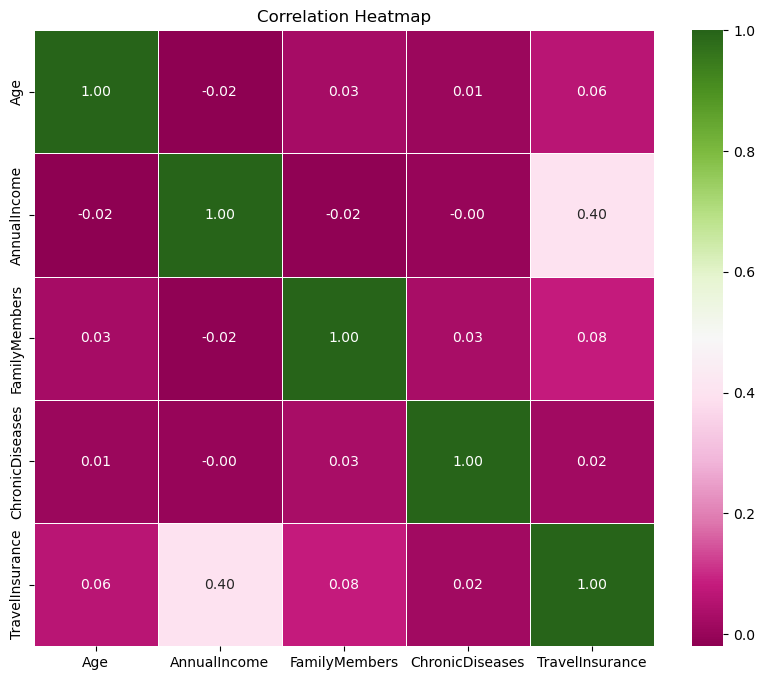

In [44]:
plt.figure(figsize=(10,8))

sns.heatmap(TrIns.corr(numeric_only=True),
            annot=True,
            cmap='PiYG',
            fmt='.2f',
            linewidths=0.5)

plt.title('Correlation Heatmap')
plt.show()

In [45]:
TrIns.head()

,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,31,Government Sector,Yes,400000,6,1,No,No,0
1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1
3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0
4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0


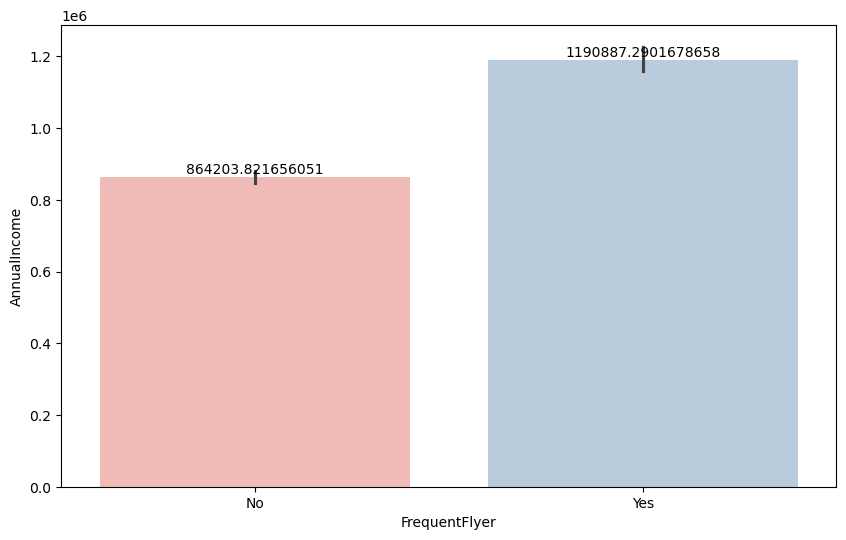

In [46]:
plt.figure(figsize=(10,6))
ax=sns.barplot(data=TrIns,x='FrequentFlyer',y='AnnualIncome',palette='Pastel1')
for p in ax.patches:
  ax.annotate(
        format((p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom')
plt.show()

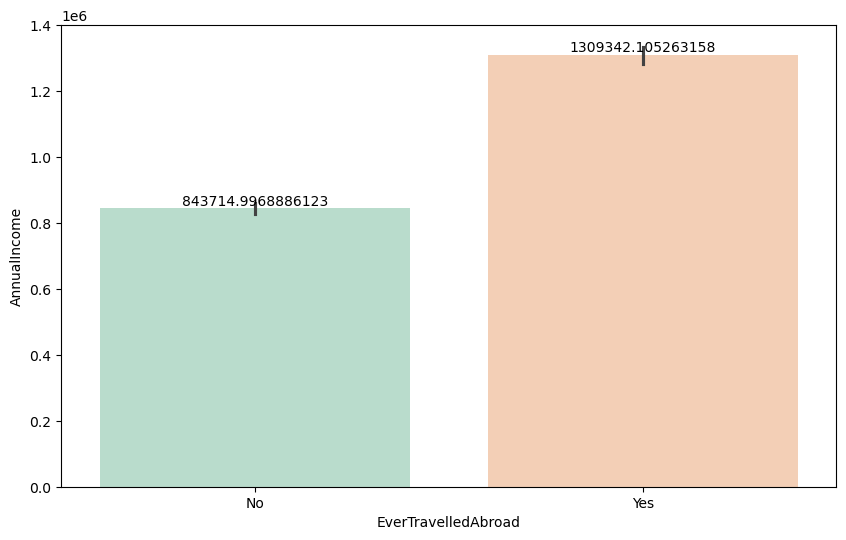

In [47]:
plt.figure(figsize=(10,6))
ax=sns.barplot(data=TrIns,x='EverTravelledAbroad',y='AnnualIncome',palette='Pastel2')
for p in ax.patches:
  ax.annotate(
        format((p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom')
plt.show()

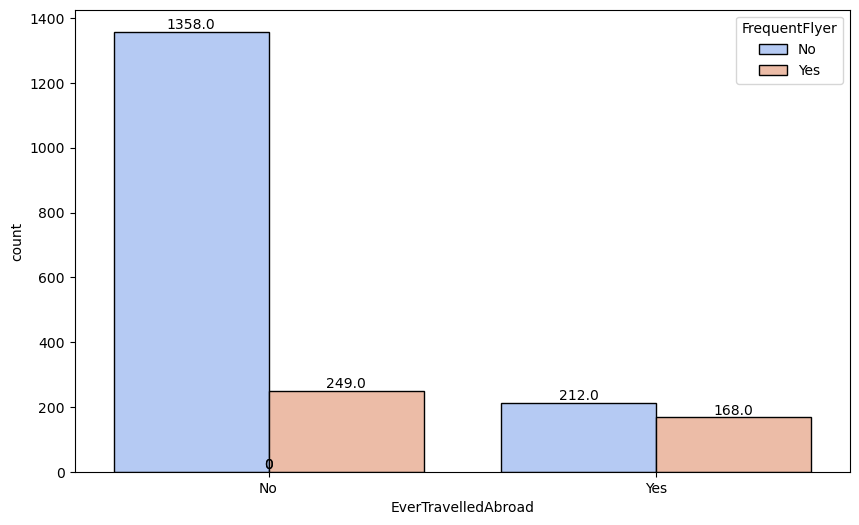

In [48]:
plt.figure(figsize=(10,6))
ax=sns.countplot(data=TrIns,x='EverTravelledAbroad',hue='FrequentFlyer',palette='coolwarm',edgecolor='black')
for p in ax.patches:
  ax.annotate(
        format((p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom')
plt.show()

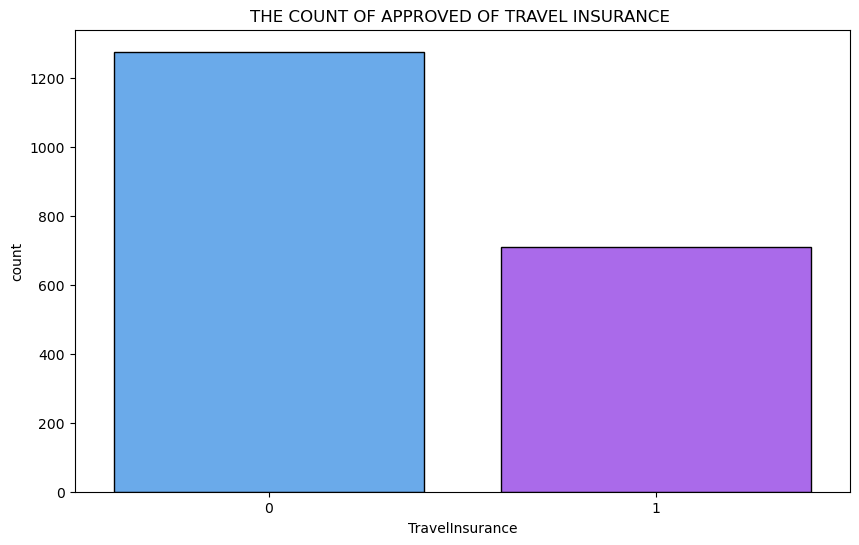

In [54]:
plt.figure(figsize=(10,6))
sns.countplot(data=TrIns,x='TravelInsurance',palette='cool',edgecolor='black')
plt.title('THE COUNT OF APPROVED OF TRAVEL INSURANCE ')
plt.show()

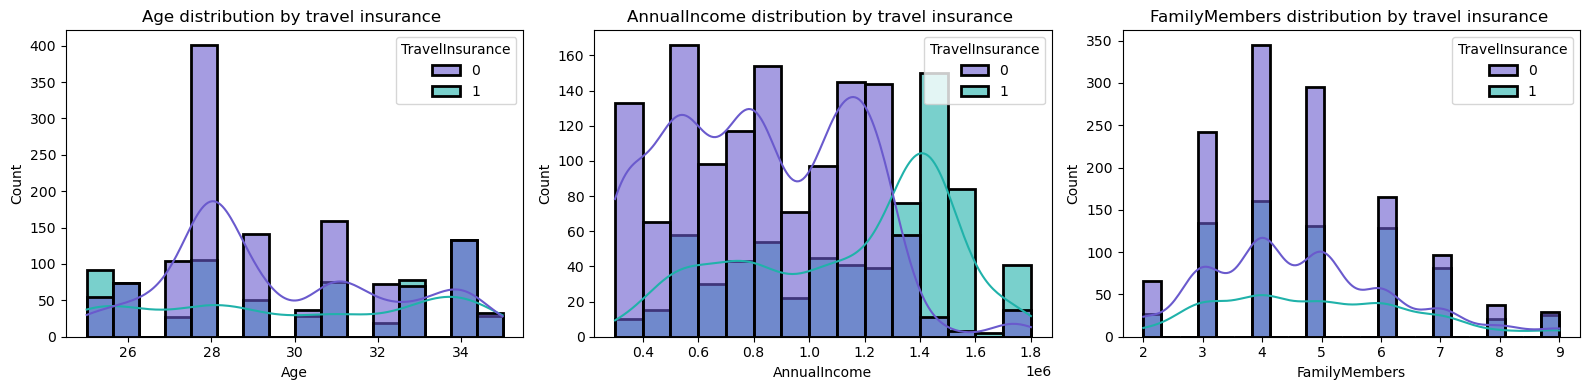

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["Age", "AnnualIncome", "FamilyMembers"]):
    sns.histplot(data=TrIns, x=col, hue="TravelInsurance", kde=True, ax=ax, palette=['#6A5ACD', '#20B2AA'], alpha=0.6,edgecolor='black',linewidth=2)
    ax.set_title(f"{col} distribution by travel insurance ")
plt.tight_layout()
plt.show()

In [87]:
TrIns.groupby("TravelInsurance")[["Age", "AnnualIncome", "FamilyMembers"]].mean().round(1)

,Age,AnnualIncome,FamilyMembers
TravelInsurance,,,
0,29.5,821299.9,4.7
1,29.9,1133239.4,4.9


FEATURE ENIGINEERING 

In [98]:
TrIns['FrequentFlyer']=TrIns['FrequentFlyer'].map({'Yes':1,'No':0})
TrIns['EverTravelledAbroad']=TrIns['EverTravelledAbroad'].map({'Yes':1,'No':0})
TrIns['GraduateOrNot']=TrIns['GraduateOrNot'].map({'Yes':1,'No':0})
TrIns['Employment Type']=TrIns['Employment Type'].map({'Government Sector':1,'Private Sector/Self Employed':0})
TrIns.head()

,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,31,1,1,400000,6,1,0,0,0
1,31,0,1,1250000,7,0,0,0,0
2,34,0,1,500000,4,1,0,0,1
3,28,0,1,700000,3,1,0,0,0
4,28,0,1,700000,8,1,1,0,0


In [99]:
TrIns["IncomePerFamilyMember"] = TrIns["AnnualIncome"] / TrIns["FamilyMembers"]
TrIns["TravelScore"] = TrIns["FrequentFlyer"] + TrIns["EverTravelledAbroad"]
TrIns.head()

,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance,IncomePerFamilyMember,TravelScore
0,31,1,1,400000,6,1,0,0,0,66666.666667,0
1,31,0,1,1250000,7,0,0,0,0,178571.428571,0
2,34,0,1,500000,4,1,0,0,1,125000.000000,0
3,28,0,1,700000,3,1,0,0,0,233333.333333,0
4,28,0,1,700000,8,1,1,0,0,87500.000000,1


In [100]:
data_x=TrIns.drop('TravelInsurance',axis=1)

In [101]:
data_x.head()

,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,IncomePerFamilyMember,TravelScore
0,31,1,1,400000,6,1,0,0,66666.666667,0
1,31,0,1,1250000,7,0,0,0,178571.428571,0
2,34,0,1,500000,4,1,0,0,125000.000000,0
3,28,0,1,700000,3,1,0,0,233333.333333,0
4,28,0,1,700000,8,1,1,0,87500.000000,1


In [102]:
data_y=TrIns['TravelInsurance']
data_y.head()

0    0
1    0
2    1
3    0
4    0
Name: TravelInsurance, dtype: int64

DATA TRANING AND SPLITTING 

In [105]:
from sklearn.model_selection import train_test_split  
data_x_train, data_x_test, data_y_train, data_y_test = train_test_split(
    data_x, 
    data_y, 
    test_size=0.2, 
    random_state=42  
)

In [106]:
len(data_x_train),len(data_x_test)

(1589, 398)

 MODEL TRAINNING AND EVALUTION METRIX 

In [131]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import(accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,mean_squared_error,mean_absolute_error,r2_score)
rf = RandomForestClassifier()

In [134]:
rf.fit(data_x_train,data_y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [142]:
RandamForestClassifierScore=rf.score(data_x_test,data_y_test)
print("Score:",RandamForestClassifierScore)
data_y_pred = rf.predict(data_x_test) 
accuracy = accuracy_score(data_y_test, data_y_pred)
print("Accuracy:", accuracy)
precision=precision_score(data_y_test,data_y_pred)
print("Precision:",precision)
recall = recall_score(data_y_test, data_y_pred)
print("Recall:", recall)
f1 = f1_score(data_y_test, data_y_pred)
print("F1 Score:", f1)
print("Confusion Matrix:\n", confusion_matrix(data_y_test, data_y_pred))


Score: 0.8241206030150754
Accuracy: 0.8241206030150754
Precision: 0.8141592920353983
Recall: 0.6524822695035462
F1 Score: 0.7244094488188977
Confusion Matrix:
 [[236  21]
 [ 49  92]]


In [112]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()

In [113]:
lr.fit(data_x_train,data_y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [144]:
LogisticRegressionScore=lr.score(data_x_test,data_y_test)
print("Score:",LogisticRegressionScore)
data_y_pred = lr.predict(data_x_test) 
accuracy = accuracy_score(data_y_test, data_y_pred)
print("Accuracy:", accuracy)
precision=precision_score(data_y_test,data_y_pred)
print("Precision:",precision)
recall = recall_score(data_y_test, data_y_pred)
print("Recall:", recall)
f1 = f1_score(data_y_test, data_y_pred)
print("F1 Score:", f1)
print("Confusion Matrix:\n", confusion_matrix(data_y_test, data_y_pred))

Score: 0.7487437185929648
Accuracy: 0.7487437185929648
Precision: 0.7157894736842105
Recall: 0.48226950354609927
F1 Score: 0.576271186440678
Confusion Matrix:
 [[230  27]
 [ 73  68]]


In [117]:
from sklearn.neighbors import KNeighborsClassifier
kn=KNeighborsClassifier()

In [118]:
kn.fit(data_x_train,data_y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [145]:
KNeighborsClassifierScore=kn.score(data_x_test,data_y_test)
print("Score:",KNeighborsClassifierScore)
data_y_pred = kn.predict(data_x_test) 
accuracy = accuracy_score(data_y_test, data_y_pred)
print("Accuracy:", accuracy)
precision=precision_score(data_y_test,data_y_pred)
print("Precision:",precision)
recall = recall_score(data_y_test, data_y_pred)
print("Recall:", recall)
f1 = f1_score(data_y_test, data_y_pred)
print("F1 Score:", f1)
print("Confusion Matrix:\n", confusion_matrix(data_y_test, data_y_pred))

Score: 0.7989949748743719
Accuracy: 0.7989949748743719
Precision: 0.7850467289719626
Recall: 0.5957446808510638
F1 Score: 0.6774193548387096
Confusion Matrix:
 [[234  23]
 [ 57  84]]


In [120]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()

In [122]:
dt.fit(data_x_train,data_y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [146]:
DecisionTreeClassifierScore=dt.score(data_x_test,data_y_test)
print("Score:",DecisionTreeClassifierScore)
data_y_pred = dt.predict(data_x_test) 
accuracy = accuracy_score(data_y_test, data_y_pred)
print("Accuracy:", accuracy)
precision=precision_score(data_y_test,data_y_pred)
print("Precision:",precision)
recall = recall_score(data_y_test, data_y_pred)
print("Recall:", recall)
f1 = f1_score(data_y_test, data_y_pred)
print("F1 Score:", f1)
print("Confusion Matrix:\n", confusion_matrix(data_y_test, data_y_pred))

Score: 0.8040201005025126
Accuracy: 0.8040201005025126
Precision: 0.752
Recall: 0.6666666666666666
F1 Score: 0.706766917293233
Confusion Matrix:
 [[226  31]
 [ 47  94]]


In [149]:
comparison = pd.DataFrame({

    'Model': [
        'Random Forest',
        'Logistic Regression',
        'KNN',
        'Decision Tree'
    ],

    'Accuracy': [
        0.8241206030150754,
        0.7487437185929648,
        0.7989949748743719,
        0.8040201005025126
    ],

    'Precision': [
        0.8141592920353983,
        0.7157894736842105,
        0.7850467289719626,
        0.7520000000000000
    ],

    'Recall': [
        0.6524822695035462,
        0.4822695035460993,
        0.5957446808510638,
        0.6666666666666666
    ],

    'F1 Score': [
        0.7244094488188977,
        0.5762711864406780,
        0.6774193548387096,
        0.7067669172932330
    ]

})
comparison = comparison.round(4)
print(comparison)

                 Model  Accuracy  Precision  Recall  F1 Score
0        Random Forest    0.8241     0.8142  0.6525    0.7244
1  Logistic Regression    0.7487     0.7158  0.4823    0.5763
2                  KNN    0.7990     0.7850  0.5957    0.6774
3        Decision Tree    0.8040     0.7520  0.6667    0.7068


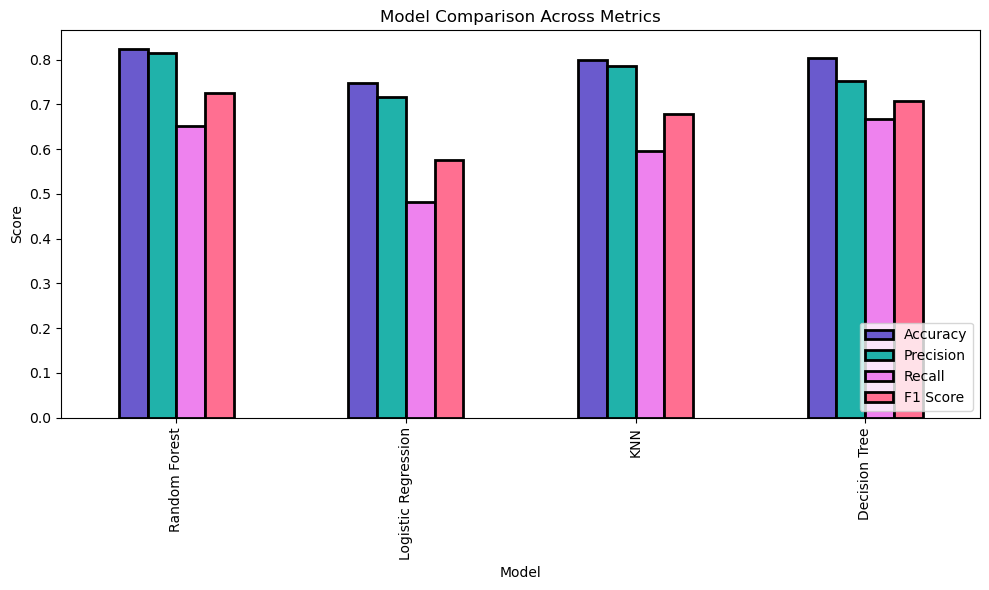

In [169]:
fig, ax = plt.subplots(figsize=(10,6))
plot_df = comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score",]]
plot_df.plot(kind="bar", ax=ax, color= ['#6A5ACD', '#20B2AA', 'violet', '#FF6F91'],edgecolor='black',linewidth=2)
ax.set_title("Model Comparison Across Metrics")
ax.set_ylabel("Score")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

FROM THIS ALL MODAL WE CAN DECALRE RANDAM FOREST IS BEST FOR PREDICION WITH HAS HIGH SCORES AND PRECISION AND F1 SCORE

SO NOW LET US CHECK THE MODAL WITH SAMPLE UNSEEN DATA TO CHECK THE DATA IS WORKING OR NOT

In [184]:
def build_customer_row(age, employment_type, graduate, annual_income,
                       family_members, chronic_disease,
                       frequent_flyer, ever_travelled_abroad):

    row = pd.DataFrame([{
        "Age": age,
        "Employment Type": employment_type,
        "GraduateOrNot": 1 if graduate == "Yes" else 0,
        "AnnualIncome": annual_income,
        "FamilyMembers": family_members,
        "ChronicDiseases": chronic_disease,
        "FrequentFlyer": 1 if frequent_flyer == "Yes" else 0,
        "EverTravelledAbroad": 1 if ever_travelled_abroad == "Yes" else 0,
    }])

    row["IncomePerFamilyMember"] = row["AnnualIncome"] / row["FamilyMembers"]
    row["TravelScore"] = row["FrequentFlyer"] + row["EverTravelledAbroad"]

    row = row.reindex(columns=X.columns, fill_value=0)

    return row
    print("Predictions using Random Forest\n")

    for i, cust in enumerate(sample_customers, start=1):
        row = build_customer_row(**cust)
        pred = rf.predict(row)[0]
        prob = rf.predict_proba(row)[0][1]
        if pred == 1:
            result = "Will Purchase Travel Insurance"
        else:
            result = "Will Not Purchase Travel Insurance"
            print(f"Customer {i}")
            print(result)
            print(f"Probability : {prob:.2%}")
            print("-"*40)

In [189]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(data_x_train,data_y_train)
customers = pd.DataFrame({

    'Age':[29,45,24],

    'Employment Type':[0,1,0],

    'GraduateOrNot':[1,1,0],

    'AnnualIncome':[1400000,450000,650000],

    'FamilyMembers':[3,5,2],

    'ChronicDiseases':[0,1,0],

    'FrequentFlyer':[1,0,0],

    'EverTravelledAbroad':[1,0,1]

})

customers['IncomePerFamilyMember'] = (
    customers['AnnualIncome']
    /
    customers['FamilyMembers']
)

customers['TravelScore'] = (
    customers['FrequentFlyer']
    +
    customers['EverTravelledAbroad']
)

customers = customers[data_x_train.columns]


prediction = rf.predict(customers)

probability = rf.predict_proba(customers)

customers['Prediction'] = prediction

customers['Prediction'] = customers['Prediction'].map({
    0:'Will Not Purchase',
    1:'Will Purchase'
})

customers['Probability'] = probability[:,1]

print(customers)

   Age  Employment Type  GraduateOrNot  AnnualIncome  FamilyMembers  \
0   29                0              1       1400000              3   
1   45                1              1        450000              5   
2   24                0              0        650000              2   

   ChronicDiseases  FrequentFlyer  EverTravelledAbroad  IncomePerFamilyMember  \
0                0              1                    1          466666.666667   
1                1              0                    0           90000.000000   
2                0              0                    1          325000.000000   

   TravelScore         Prediction  Probability  
0            2      Will Purchase     0.890000  
1            0  Will Not Purchase     0.128333  
2            1  Will Not Purchase     0.315833  
